### 프로젝트와 사용자 프롬프트의 유사도 검증 테스트

- 사용자가 프로젝트에 대해서 질문을 했을 때, 이 질문에 대해서 답변할 근거(벡터스토어)가 있는지 확인
- 추가적으로, 답변의 품질을 보장할 수 있는지 검사

===

### 아이디어
#### 1. 프롬프팅 된 GPT-Nano 또는 Luna 모델
- 비용이 발생하며, 레이턴시를 예측할 수 없음
- 타사의 Saas 시스템에 의존 관계가 있음
- 오판의 가능성이 매우 큼

#### 2. Lora 또는 Fine 튜닝된 모델 (gemma4 등)
- GPU 인스턴스 유지 비용 발생
- 새로운 프로젝트를 벡터 스토어에 넣을 때 기록하고, 24시간마다 재학습 시켜야 함


#### 3. 임베딩 후 수학적으로 근사치를 구함
- **아이디어**
    - 임베딩 후에 벡터 스토어에서 ``가장 가까운`` 스칼라와 떨어진 거리를 O(1)로 검색하여 그 떨어진 거리가 특정 값 k보다 작을 때 답변
        - 문제점: 이 방식으로는 O(1)은 커녕 O(log n)도 불가능함

#### 4. TOP-K 이용
- **아이디어**
    - 기존의 스칼라로 검색했던 것 대신, 벡터를 이용하여 ``코사인 유사도``를 이용하여 유사한 벡터 TOP-3개를 불러옴
        - 이때 TOP-3의 벡터들의 평균이 특정 값 k보다 작을 때 답변 (O(1))
        - 단, 유저 프롬프트와 유사한 것일 뿐(답변할 가지는 있을 수 있음), 답변의 품질이 좋다고 보장할 수 없음
        - 해결하기 위해서 각 프롬프트에 대해서 주제별 클러스터를 설정하고, 각 클러스터에 대한 평균 스칼라를 설정함
        - 이 평균 스칼라를 비교하여, 답변의 품질이 어느정도일지 LLM에 넘기기 전에 유추 가능할 것으로 보임

In [1]:
# 라이브러리 선언
import os
import sys

from fastapi import APIRouter, Depends, HTTPException, status
import faiss
import uuid

from typing import Optional, List, Dict

from langchain_core.documents import Document

from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.document_loaders import TextLoader
from langchain_community.retrievers import BM25Retriever

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai.embeddings import OpenAIEmbeddings

from dotenv import load_dotenv
load_dotenv()


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_28292\2272464288.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


True

In [2]:
# FAISS 벡터 DB

class FAISSManager:
    def __init__(self, db_path: str = "faiss_index"):
        self.db_path = db_path

        self.embeddings = OpenAIEmbeddings()
        
        if os.path.exists(self.db_path):
            self.db = FAISS.load_local(
                folder_path=self.db_path, 
                embeddings=self.embeddings, 
                allow_dangerous_deserialization=True
            )
        else:
            self.db = FAISS(
                embedding_function=self.embeddings,
                index=faiss.IndexFlatL2(1536),
                docstore=InMemoryDocstore(),
                index_to_docstore_id={},
            )
        
        self.text_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=200)

    def add_project_document(self, file_path: str, project_id: str) -> List[str]:
        """문서를 로드, 청크화하여 메타데이터와 함께 추가합니다."""
         
        loader = TextLoader(file_path, encoding="utf-8")
        docs = loader.load()
        
        split_docs = self.text_splitter.split_documents(docs)
        doc_ids = [str(uuid.uuid4()) for _ in split_docs]
        
        for i, doc in enumerate(split_docs):
            doc.metadata["doc_type"] = "project "
            doc.metadata["project_id"] = project_id
            doc.metadata["chunk_index"] = i
            doc.metadata["total_chunks"] = len(split_docs)
            
        self.db.add_documents(split_docs, ids=doc_ids)
        self.db.save_local(self.db_path)
        
        return doc_ids

    def search_documents(self, query: str, k: int = 3, filter_dict: Optional[Dict] = None, distance_threshold: float = 0.4):
        """임계값을 넘지 않는 문서만 반환하고, 디버깅을 위해 점수를 출력합니다."""

        docs_and_scores = self.db.similarity_search_with_score(query, k=k, filter=filter_dict)
        
        valid_docs = []
        for doc, score in docs_and_scores:
            
            if score <= distance_threshold:
                valid_docs.append(doc)
                
        return valid_docs

    def hybrid_search(self, query: str, k: int = 3, filter_dict: dict = None):
        """ BM25와 FAISS 검색 결과를 RRF(Reciprocal Rank Fusion) 알고리즘으로 결합합니다.
            - 대한민국 법에 근거하여 위반 사항이 있는지 구제척으로 판단하기 위한 자료 검색
        """
        
        all_docs = list(self.db.docstore._dict.values())
        
        if filter_dict:
            filtered_docs = [
                doc for doc in all_docs 
                if all(doc.metadata.get(key) == value for key, value in filter_dict.items())
            ]
        else:
            filtered_docs = all_docs
            
        if not filtered_docs:
            return []

        bm25_retriever = BM25Retriever.from_documents(filtered_docs)
        bm25_retriever.k = min(20, len(filtered_docs)) 
        bm25_docs = bm25_retriever.invoke(query)

        faiss_docs = self.db.similarity_search(query, k=min(20, len(filtered_docs)), filter=filter_dict)
        rrf_score = {}
        
        def add_to_rrf(docs, weight):
            """ RRF 공식: 가중치 * (1 / (순위 + 상수 60)) """

            for rank, doc in enumerate(docs):
                identifier = doc.metadata.get('law_name') or doc.metadata.get('project_id') or 'doc'
                doc_id = f"{identifier}_{doc.metadata.get('chunk_index', 0)}"
                
                if doc_id not in rrf_score:
                    rrf_score[doc_id] = {"doc": doc, "score": 0.0}
                
                rrf_score[doc_id]["score"] += weight * (1 / (rank + 60))

        add_to_rrf(bm25_docs, 0.6)
        add_to_rrf(faiss_docs, 0.4)

        reranked_results = sorted(rrf_score.values(), key=lambda x: x["score"], reverse=True)
        
        return [item["doc"] for item in reranked_results[:k]]

    def get_full_project_document(self, project_id: str) -> str:
        all_docs = list(self.db.docstore._dict.values())
        
        project_chunks = [
            doc for doc in all_docs 
            if doc.metadata.get("project_id") == project_id
        ]
        
        if not project_chunks:
            return ""
            
        project_chunks.sort(key=lambda x: x.metadata.get("chunk_index", 0))
        full_text = "\n\n".join([doc.page_content for doc in project_chunks])
        
        return full_text
    
    def add_documents(self, documents: List[Document], ids: List[str] = None):
        """외부에서 Document 리스트를 직접 받아 적재합니다. """

        self.db.add_documents(documents, ids=ids)
        self.db.save_local(self.db_path)
        
    def delete_documents(self, doc_ids: List[str]):
        """문서 ID 리스트를 받아 벡터 DB에서 삭제합니다."""

        if doc_ids:
            self.db.delete(doc_ids)
            self.db.save_local(self.db_path)
            self.logger.info(f"{len(doc_ids)} 개의 청크가 삭제되었습니다.")

    def delete_documents_by_metadata(self, filter_dict: dict):
        """메타데이터 조건을 만족하는 모든 문서를 벡터 DB에서 삭제합니다. """
        
        target_ids = []
        for doc_id, doc in self.db.docstore._dict.items():
            is_match = all(doc.metadata.get(key) == value for key, value in filter_dict.items())
            
            if is_match:
                target_ids.append(doc_id)
                
        if target_ids:
            self.delete_documents(target_ids)

faiss_manager = FAISSManager(db_path="src/data/faiss_index")

## A~G 비교 실험

이 아래 셀은 위의 이전 프로젝트용 `FAISSManager`와 독립적인 오프라인 benchmark입니다. 운영 승격 결과가 아니며 FAISS/Hashing embedder는 smoke test와 pgvector 비교 baseline에만 사용합니다.

- `train`: C~E 경량 gate 학습
- `validation`: 모든 방법의 abstain threshold 선택
- `test`: 고정된 최종 비교
- A: top-1 cosine, B: 중복 완화 top-3 평균, C: semantic+BM25, D: cluster feature 추가, E: 전체 feature gate
- F: 캐시된 LLM evaluator, G: E의 경계 구간에서만 LLM fallback

> 아래 데모 corpus와 label은 코드 실행 검증용입니다. 성능 결론에는 실제 문서와 사람이 확정한 query label을 사용해야 합니다.

In [3]:
from pathlib import Path
from pprint import pprint

from similarity_benchmark import (
    HashingEmbedder,
    QueryCase,
    chunks_from_paths,
    chunks_from_texts,
    compact_results,
    embed_corpus,
    embed_queries,
    plot_benchmark_report,
    run_benchmark,
    select_clusters,
)

In [4]:
# 이 셀은 실행 경로 검증용입니다. 숫자를 품질 결과로 해석하지 마세요.
demo_documents = {
    "contract": "계약 해지는 30일 전에 서면 통보한다. 손해배상 책임은 계약 금액을 한도로 한다.",
    "tax": "공급가액에 부가가치세 10퍼센트를 더한다. 세금과 합계는 결정적인 계산 도구로 산출한다.",
    "quotation": "견적 할인은 공급가액에서 먼저 차감한다. 발행된 견적은 직접 수정하지 않고 새 revision을 만든다.",
    "outcome": "완료 프로젝트에는 실제 공수와 최종 금액을 기록하여 다음 검색 근거로 활용한다.",
    "security": "모든 문서 검색에는 workspace_id를 적용하고 다른 workspace의 자료 접근을 차단한다.",
    "evidence": "모든 견적 항목은 source, evidence 또는 명시적인 assumption을 가져야 한다.",
}

cases = [
    QueryCase("tr-1", "계약 해지 서면 통보 기간", "train", True, ("contract",)),
    QueryCase("tr-2", "부가가치세 10퍼센트 계산", "train", True, ("tax",)),
    QueryCase("tr-3", "견적 할인 후 새 revision", "train", True, ("quotation",)),
    QueryCase("tr-4", "오늘 서울 날씨", "train", False),
    QueryCase("tr-5", "주식 매수 추천", "train", False),
    QueryCase("tr-6", "감기 치료 방법", "train", False),
    QueryCase("va-1", "계약 손해배상 책임 한도", "validation", True, ("contract",)),
    QueryCase("va-2", "완료 프로젝트 실제 공수 기록", "validation", True, ("outcome",)),
    QueryCase("va-3", "문서 검색 workspace 격리", "validation", True, ("security",)),
    QueryCase("va-4", "축구 경기 결과", "validation", False),
    QueryCase("va-5", "호텔 예약 가격", "validation", False),
    QueryCase("va-6", "파스타 조리법", "validation", False),
    QueryCase("te-1", "견적 항목의 근거와 assumption", "test", True, ("evidence",), True),
    QueryCase("te-2", "발행 견적을 수정하는 방법", "test", True, ("quotation",), True),
    QueryCase("te-3", "다른 workspace 문서 접근", "test", True, ("security",), True),
    QueryCase("te-4", "내일 환율 전망", "test", False, (), False),
    QueryCase("te-5", "비트코인 시세", "test", False, (), False),
    QueryCase("te-6", "항공권 환불 규정", "test", False, (), True),
]

chunks = chunks_from_texts(demo_documents, chunk_size=120, overlap=20) 
embedder = HashingEmbedder(dimension=384)
print(f"demo chunks={len(chunks)}, cases={len(cases)}")

demo chunks=6, cases=18


### 실제 PDF/TXT로 전환

아래 셀의 `USE_REAL_DOCUMENTS`를 `True`로 바꾸고 경로와 label을 채웁니다. `answerable`은 해당 corpus만으로 충분한 근거가 있는지를 사람이 판정한 값입니다. `llm_accept`는 별도 실행한 LLM evaluator 결과를 캐시해 넣으며, 없으면 F/G는 자동으로 제외됩니다.

각 split에 answerable/unanswerable 사례가 모두 필요합니다. 의미 있는 비교에는 split별 최소 수십 건과 frozen test set을 권장합니다.

In [5]:
USE_REAL_DOCUMENTS = False
DOCUMENT_PATHS = [
    # Path(r"C:\\path\\to\\document.pdf"),
    # Path(r"C:\\path\\to\\document.txt"),
]
REAL_CASES = [
    # QueryCase("train-001", "질문", "train", True, ("실제 document_id",)),
    # QueryCase("validation-001", "질문", "validation", False),
    # QueryCase("test-001", "질문", "test", True, (), llm_accept=True),
]

if USE_REAL_DOCUMENTS:
    from langchain_openai import OpenAIEmbeddings

    if not DOCUMENT_PATHS:
        raise ValueError("DOCUMENT_PATHS를 먼저 채우세요.")
    chunks = chunks_from_paths(
        DOCUMENT_PATHS,
        workspace_id="offline-similarity-eval",
        chunk_size=600,
        overlap=200,
    )
    print("document_ids=", sorted({chunk.document_id for chunk in chunks}))
    if not REAL_CASES:
        raise ValueError("출력된 document_id를 참고해 REAL_CASES를 채우세요.")
    # model/dimension은 결과 metadata와 함께 고정·기록해야 합니다.
    embedder = OpenAIEmbeddings(model="text-embedding-3-small", dimensions=1536)
    cases = REAL_CASES
    print(f"real chunks={len(chunks)}, cases={len(cases)}")

In [6]:
corpus_vectors = embed_corpus(chunks, embedder)
query_vectors = embed_queries(cases, embedder)
clusters = select_clusters(
    corpus_vectors,
    max_k=12,
    min_cluster_size=2,
    min_silhouette=0.05,
    seed=42,
)

report = run_benchmark(
    chunks,
    corpus_vectors,
    cases,
    query_vectors,
    clusters=clusters,
    max_false_accept_rate=0.10,
    uncertain_band=0.10,
)

print("cluster")
pprint(report["cluster"])
print("\nretrieval")
pprint(report["retrieval"])
print("\nA~G")
pprint(compact_results(report), sort_dicts=False)
print("\nfeature latency")
print(round(report["feature_extraction_ms_per_query"], 4), "ms/query (embedding·LLM 제외)")

cluster
{'candidates': [{'k': 2,
                 'min_cluster_size': 3,
                 'silhouette': 0.056003619937099215},
                {'k': 3,
                 'min_cluster_size': 2,
                 'silhouette': 0.0513959912770521}],
 'chosen_k': 2,
 'radii': [0.3806456923484802, 0.4042835533618927],
 'silhouette': 0.056003619937099215,
 'sizes': [3, 3]}

retrieval
{'evidence_coverage_at_3': 1.0, 'mrr': 0.8333333333333334, 'recall_at_3': 1.0}

A~G
[{'method': 'A_top1',
  'accuracy': 0.5,
  'precision': 0.5,
  'recall': 0.3333,
  'f1': 0.4,
  'coverage': 0.3333,
  'false_accept_rate': 0.3333,
  'false_reject_rate': 0.6667,
  'brier': 0.2988},
 {'method': 'B_top3_mean',
  'accuracy': 0.6667,
  'precision': 1.0,
  'recall': 0.3333,
  'f1': 0.5,
  'coverage': 0.1667,
  'false_accept_rate': 0.0,
  'false_reject_rate': 0.6667,
  'brier': 0.174},
 {'method': 'C_semantic_bm25',
  'accuracy': 0.6667,
  'precision': 1.0,
  'recall': 0.3333,
  'f1': 0.5,
  'coverage': 0.1667,
  'false_

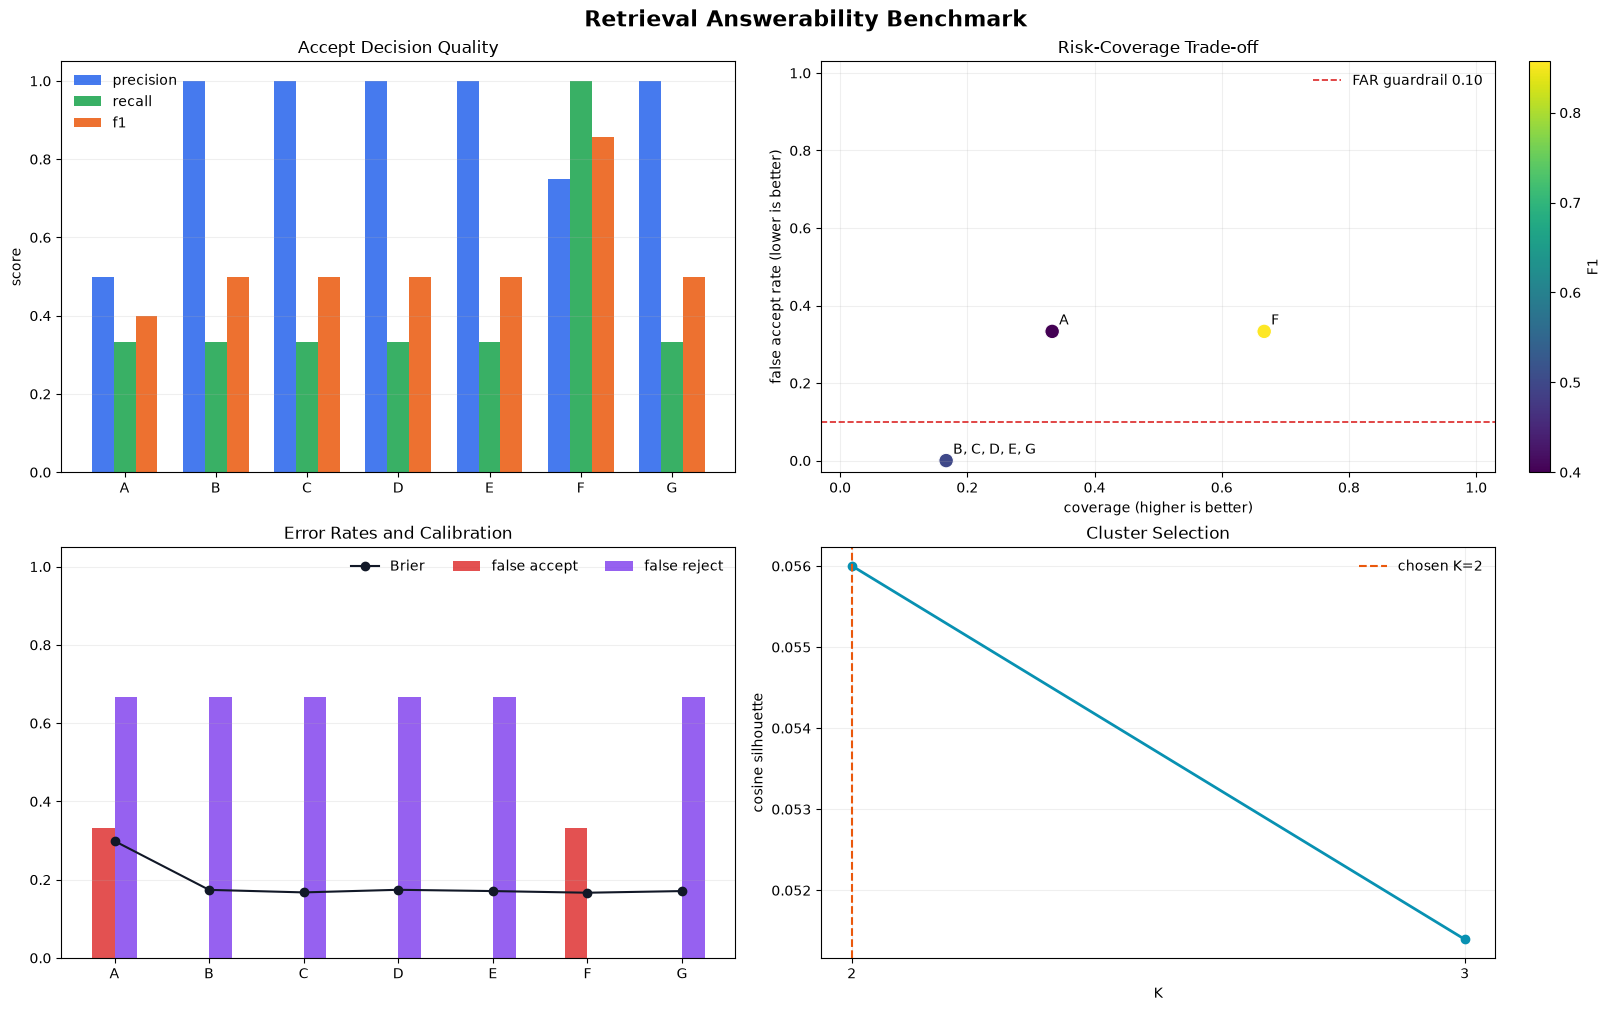

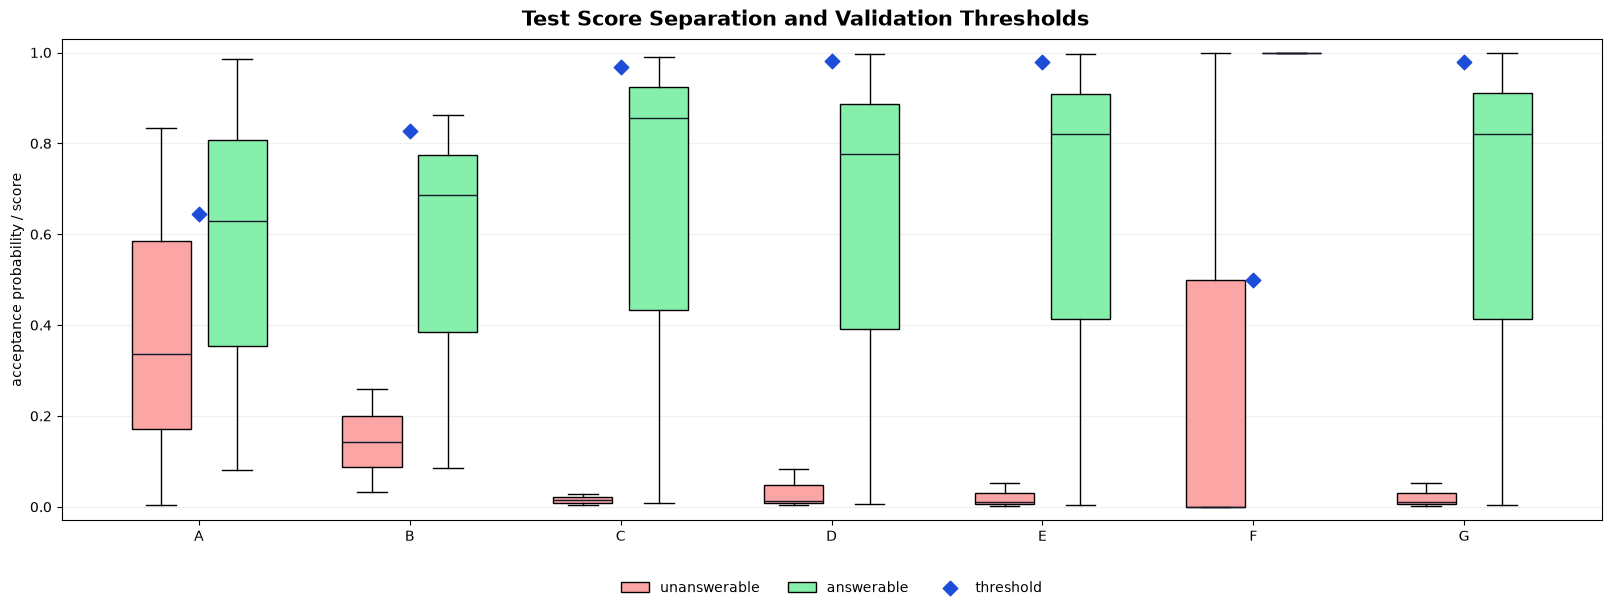

In [7]:
# None이면 notebook에만 표시합니다. PNG가 필요하면 Path("artifacts/similarity_benchmark")로 변경하세요.
PLOT_OUTPUT_DIR = None

plot_result = plot_benchmark_report(
    report,
    output_dir=PLOT_OUTPUT_DIR,
    show=True,
)
if plot_result["saved_paths"]:
    pprint(plot_result["saved_paths"])

### 판정 기준

1. `false_accept_rate`를 먼저 제한하고 그 안에서 recall/coverage가 높은 방법을 선택합니다.
2. C 대비 D가 frozen test에서 개선되지 않으면 cluster feature를 제거합니다.
3. E 대비 G의 품질 이득과 `llm_fallback_rate`를 함께 비교합니다.
4. `Recall@3`와 MRR이 낮다면 gate보다 retrieval/chunking을 먼저 개선합니다.
5. 이 표는 근거 충분성 gate 평가입니다. 실제 답변 품질은 생성 답변의 citation precision, citation coverage, correctness를 별도 평가해야 합니다.